In [3]:
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

Visualizing Patient: BraTS-GLI-00005-100


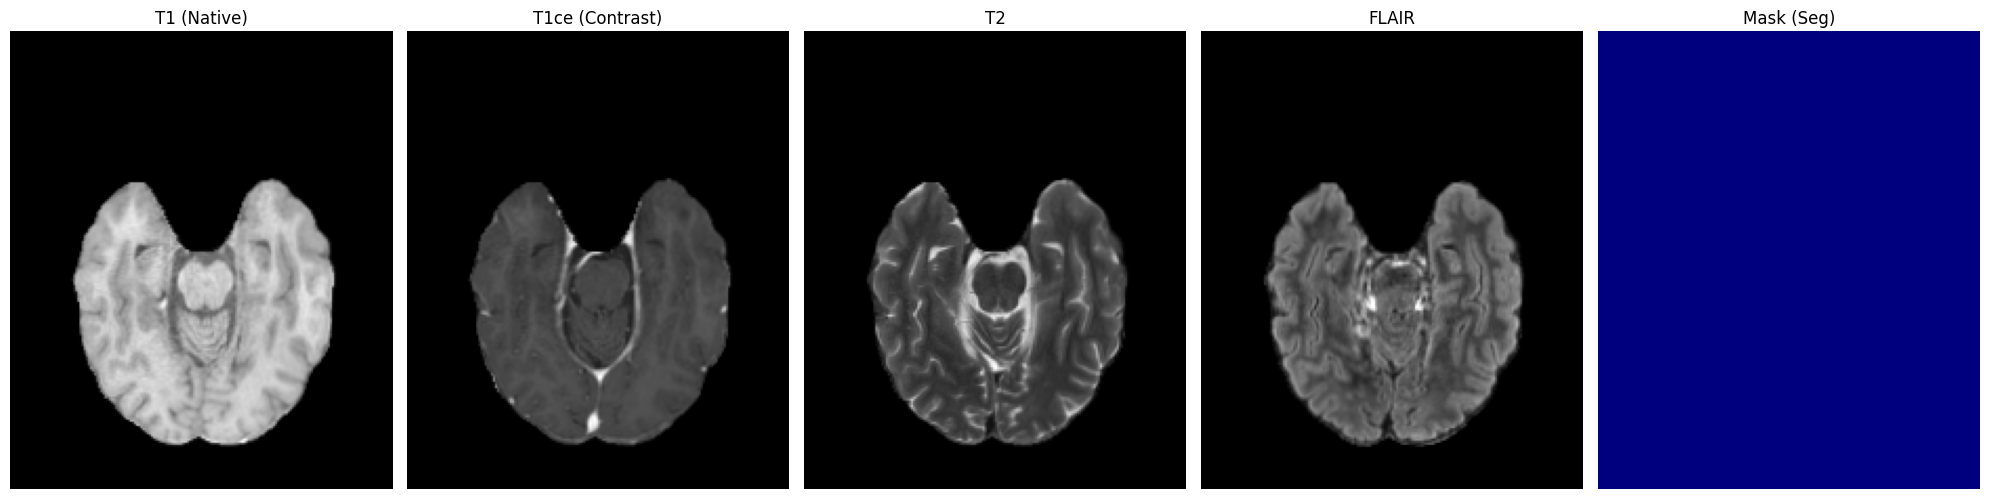

In [4]:
# 1. Load inventory
df = pd.read_csv("../data_inventory.csv")

# 2. Pick the first patient from the list
patient = df.iloc[0]
print(f"Visualizing Patient: {patient['patient_id']}")

def load_nifti(path):
    return nib.load(path).get_fdata()

# 3. Load all modalities and the mask
data = {
    "T1 (Native)": load_nifti(patient['t1n']),
    "T1ce (Contrast)": load_nifti(patient['t1c']),
    "T2": load_nifti(patient['t2w']),
    "FLAIR": load_nifti(patient['t2f']),
    "Mask (Seg)": load_nifti(patient['seg'])
}

# 4. Choose a slice
slice_idx = 75 

plt.figure(figsize=(20, 10))

for i, (name, img) in enumerate(data.items()):
    plt.subplot(1, 5, i + 1)
    
    # Rotate for better visualization
    slice_to_show = np.rot90(img[:, :, slice_idx])
    
    if name == "Mask (Seg)":
        # Show mask with a colorful palette
        plt.imshow(slice_to_show, cmap='jet')
    else:
        # Show MRI in grayscale
        plt.imshow(slice_to_show, cmap='gray')
    
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from ipywidgets import interact, IntSlider
import ipywidgets as widgets

max_slices = data["T1 (Native)"].shape[2] - 1

def interactive_viz(slice_idx):
    plt.figure(figsize=(20, 10))
    
    for i, (name, img) in enumerate(data.items()):
        plt.subplot(1, 5, i + 1)
        
        # Rotate for better visualization
        slice_to_show = np.rot90(img[:, :, slice_idx])
        
        if name == "Mask (Seg)":
            # Use vmin/vmax to ensure color consistency across empty slices
            plt.imshow(slice_to_show, cmap='jet', vmin=0, vmax=3)
        else:
            plt.imshow(slice_to_show, cmap='gray')
            
        plt.title(f"{name}\nSlice: {slice_idx}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

interact(interactive_viz, slice_idx=IntSlider(min=0, max=max_slices, step=1, value=75));

interactive(children=(IntSlider(value=75, description='slice_idx', max=181), Output()), _dom_classes=('widget-…